In [18]:
import os

os.environ['MPLCONFIGDIR'] = "/mnt/storage6/grace/plt_temp/" # setting config environment to writable directory to stop error message

import math
import datetime
import numpy as np
import xarray as xr
import netCDF4 as nc
import glob
import time

import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [90]:
ds_t4 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4-EPM151_y2019m05d25_gridT.nc")
ds_u4 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4-EPM151_y2019m05d25_gridU.nc")
ds_v4 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4-EPM151_y2019m05d25_gridV.nc")

Text(0.5, 0.98, 'ANHA4 Velocity before Grand Banks (m/s), 5/30/19')

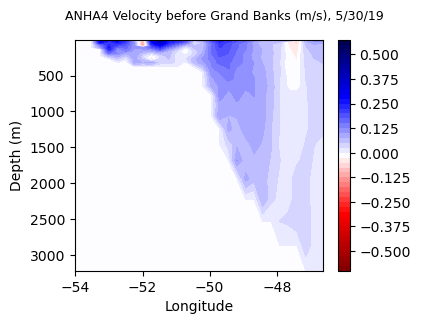

In [185]:
speedmask4 = np.ma.make_mask(ds_v4['vomecrty'][0,:44, 85+225, 55+125:85+125] > 0)
speed4 = np.sqrt(ds_u4['vozocrtx'][0,:44, 85+225, 55+125:85+125].values**2 + ds_v4['vomecrty'][0,:44, 85+225, 55+125:85+125].values**2)
speed4 = np.where(speedmask4 > 0, speed4, speed4*-1)

fig, ax = plt.subplots(figsize=(4, 3))

lab1 = ax.contourf(ds_v4.nav_lon[85+225, (55+125):(85+125)], ds_v4.depthv[:44], speed4*-1, np.arange(-.6, .6, .025), cmap = 'seismic_r')
ax.invert_yaxis()

ax.set_ylabel("Depth (m)")
ax.set_xlabel("Longitude")
fig.colorbar(lab1)
fig.suptitle("ANHA4 Velocity before Grand Banks (m/s), 5/30/19", fontsize=9)

Text(0.5, 0.98, 'ANHA4 Practical Salinity before Grand Banks, 5/30/19')

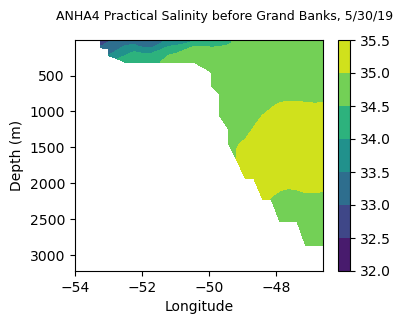

In [186]:
saltmask4 = np.ma.make_mask(ds_t4['vosaline'][0,:44, 85+225, 55+125:85+125] == 0)
salt4 = ds_t4['vosaline'][0,:44, 85+225, 55+125:85+125]
salt4 = np.where(saltmask4 == 0, salt4, np.nan)

fig, ax = plt.subplots(figsize=(4, 3))

lab2 = ax.contourf(ds_t4.nav_lon_grid_T[85+225, (55+125):(85+125)], ds_t4.deptht[:44], salt4, np.arange(32, 36, .5), cmap = 'viridis')
ax.invert_yaxis()

ax.set_ylabel("Depth (m)")
ax.set_xlabel("Longitude")
fig.colorbar(lab2)
fig.suptitle("ANHA4 Practical Salinity before Grand Banks, 5/30/19", fontsize=9)


Text(0.5, 0.98, 'ANHA4 Potential Temperature before Grand Banks, 5/30/19')

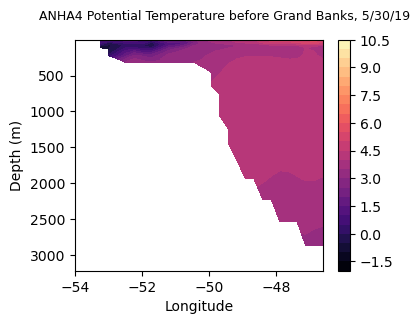

In [187]:
heatmask4 = np.ma.make_mask(ds_t4['votemper'][0,:44, 85+225, 55+125:85+125] == 0)
heat4 = ds_t4['votemper'][0,:44, 85+225, 55+125:85+125]
heat4 = np.where(heatmask4 == 0, heat4, np.nan)

fig, ax = plt.subplots(figsize=(4, 3))

lab3 = ax.contourf(ds_t4.nav_lon_grid_T[85+225, (55+125):(85+125)], ds_t4.deptht[:44], heat4, np.arange(-2, 11, .5), cmap = 'magma')
ax.invert_yaxis()

ax.set_ylabel("Depth (m)")
ax.set_xlabel("Longitude")
fig.colorbar(lab3)
fig.suptitle("ANHA4 Potential Temperature before Grand Banks, 5/30/19", fontsize=9)

In [109]:
ds_t12 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA12-EXH006/ANHA12-EXH006_y2019m05d25_gridT.nc")
ds_u12 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA12-EXH006/ANHA12-EXH006_y2019m05d25_gridU.nc")
ds_v12 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA12-EXH006/ANHA12-EXH006_y2019m05d25_gridV.nc")

Text(0.5, 0.98, 'ANHA12 Velocity before Grand Banks (m/s), 5/30/19')

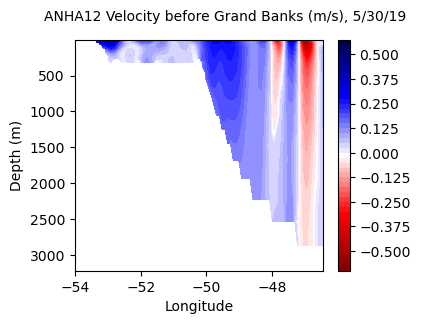

In [188]:
speedmask_12 = np.ma.make_mask(ds_v12['vomecrty'][0,:44, 930, 540:630] > 0)
speed_12 = ds_v12['vomecrty'][0,:44, 930, 540:630]
speed_12 = np.sqrt(ds_u12['vozocrtx'][0,:44, 930, 540:630].values**2 + ds_v12['vomecrty'][0,:44, 930, 540:630].values**2)
speed_12 = np.where(speedmask_12 > 0, speed_12, speed_12*-1)

fig, ax = plt.subplots(figsize=(4, 3))

lab4 = ax.contourf(ds_v12.nav_lon[930, 540:630], ds_v12.depthv[:44], speed_12*-1, np.arange(-.6, .6, .025), cmap = 'seismic_r')
ax.invert_yaxis()

ax.set_ylabel("Depth (m)")
ax.set_xlabel("Longitude")
fig.colorbar(lab4)
fig.suptitle("ANHA12 Velocity before Grand Banks (m/s), 5/30/19", fontsize=10)

Text(0.5, 0.98, 'ANHA12 Practical Salinity before Grand Banks, 5/30/19')

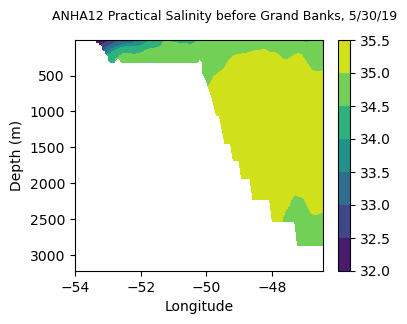

In [189]:
salt_12 = ds_t12['vosaline'][0,:44, 930, 540:630]
fig, ax = plt.subplots(figsize=(4, 3))

lab5 = ax.contourf(ds_t12.nav_lon[930, 540:630], ds_t12.deptht[:44], salt_12, np.arange(32, 36, .5), cmap = 'viridis')
ax.invert_yaxis()

ax.set_ylabel("Depth (m)")
ax.set_xlabel("Longitude")
fig.colorbar(lab5)
fig.suptitle("ANHA12 Practical Salinity before Grand Banks, 5/30/19", fontsize=9)


Text(0.5, 0.98, 'ANHA12 Potential Temperature before Grand Banks (m/s), 5/30/19')

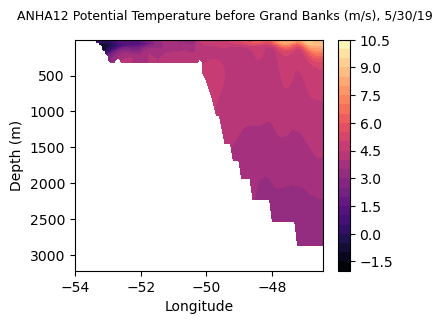

In [190]:
heat_12 = ds_t12['votemper'][0,:44, 930, 540:630]
fig, ax = plt.subplots(figsize=(4, 3))

lab6 = ax.contourf(ds_t12.nav_lon[930, 540:630], ds_t12.deptht[:44], heat_12, np.arange(-2, 11, .5), cmap = 'magma')
ax.invert_yaxis()

ax.set_ylabel("Depth (m)")
ax.set_xlabel("Longitude")
fig.colorbar(lab6)
fig.suptitle("ANHA12 Potential Temperature before Grand Banks (m/s), 5/30/19", fontsize=9)

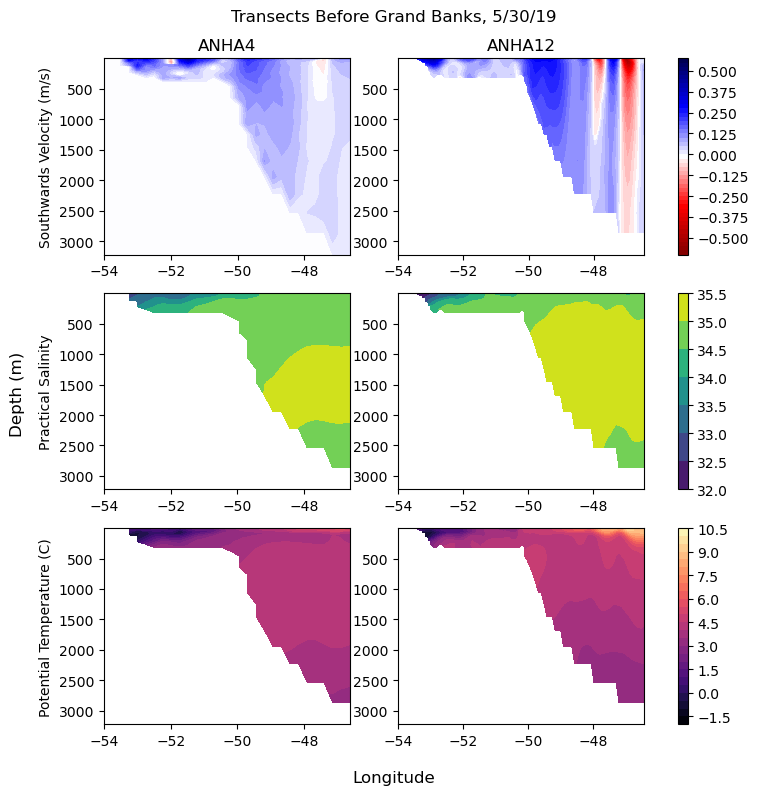

In [239]:
fig, axes = plt.subplots(3,2, figsize=(8,8))

lab1 = axes[0,0].contourf(ds_v4.nav_lon[85+225, (55+125):(85+125)], ds_v4.depthv[:44], speed4*-1, np.arange(-.6, .6, .025), cmap = 'seismic_r')
axes[0,0].invert_yaxis()

lab2 = axes[1,0].contourf(ds_t4.nav_lon_grid_T[85+225, (55+125):(85+125)], ds_t4.deptht[:44], salt4, np.arange(32, 36, .5), cmap = 'viridis')
axes[1,0].invert_yaxis()

lab3 = axes[2,0].contourf(ds_t4.nav_lon_grid_T[85+225, (55+125):(85+125)], ds_t4.deptht[:44], heat4, np.arange(-2, 11, .5), cmap = 'magma')
axes[2,0].invert_yaxis()

lab4 = axes[0,1].contourf(ds_v12.nav_lon[930, 540:630], ds_v12.depthv[:44], speed_12*-1, np.arange(-.6, .6, .025), cmap = 'seismic_r')
axes[0,1].invert_yaxis()

lab5 = axes[1,1].contourf(ds_t12.nav_lon[930, 540:630], ds_t12.deptht[:44], salt_12, np.arange(32, 36, .5), cmap = 'viridis')
axes[1,1].invert_yaxis()

lab6 = axes[2,1].contourf(ds_t12.nav_lon[930, 540:630], ds_t12.deptht[:44], heat_12, np.arange(-2, 11, .5), cmap = 'magma')
axes[2,1].invert_yaxis()

fig.supylabel("Depth (m)")
fig.supxlabel("Longitude")
fig.suptitle("Transects Before Grand Banks, 5/30/19")

axes[0,0].set_title("ANHA4")
axes[0,1].set_title("ANHA12")

axes[0,0].set_ylabel("Southwards Velocity (m/s)")
axes[1,0].set_ylabel("Practical Salinity")
axes[2,0].set_ylabel("Potential Temperature (C)")

fig.tight_layout()

fig.colorbar(lab1, ax=axes[0, :])
fig.colorbar(lab2, ax=axes[1, :])
fig.colorbar(lab3, ax=axes[2, :])

